## Extra Credit (Part 2) -- Better pretrained network

In [16]:
# you will be prompted with a window asking to grant permissions
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# fill in the path in your Google Drive in the string below. Note: do not escape slashes or spaces
import os
datadir = "/content/drive/MyDrive/CS444/assignment4"
if not os.path.exists(datadir):
  !ln -s "/content/drive/MyDrive/CS444/assignment4" $datadir # TODO: Fill your Assignment 4 path
os.chdir(datadir)
!pwd

/content/drive/MyDrive/CS444/assignment4


In [18]:
# NOTE: Loading data from Google Drive is VERY SLOW. Therefore, we download the data to a local storage
# specified by VOC_PATH.
# This means the data would have be re-downloaded everytime.
# Change this path if you are running this script locally
VOC_PATH="/content/VOC_DATA"

In [ ]:
!chmod u+x ./download_data.sh
!sed -i 's/\r//g' ./download_data.sh
!cat ./download_data.sh
!bash ./download_data.sh $VOC_PATH

#!/usr/bin/env bash

if [ "$#" -ne 1 ]; then
    echo "Usage: $0 <data_path>"
    exit 1
fi

DATA_DIR="$1"

mkdir -p "$DATA_DIR"

cd "$DATA_DIR" || { echo "Could not change directory to '$DATA_DIR'"; exit 1; }
# cd data

# download train
wget http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
tar -xf VOCtrainval_06-Nov-2007.tar
mv VOCdevkit VOCdevkit_2007
rm VOCtrainval_06-Nov-2007.tar

# download test and combine into same directory
wget http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtest_06-Nov-2007.tar
tar -xf VOCtest_06-Nov-2007.tar
mv VOCdevkit/VOC2007 VOCdevkit_2007/VOC2007test
rmdir VOCdevkit
rm VOCtest_06-Nov-2007.tar

# MIRROR Links (comment out above and uncomment out below if host.robots.ox.au.uk is down)

# wget http://pjreddie.com/media/files/VOCtrainval_06-Nov-2007.tar
# tar -xf VOCtrainval_06-Nov-2007.tar
# mv VOCdevkit VOCdevkit_2007

# wget http://pjreddie.com/media/files/VOCtest_06-Nov-2007.tar
# tar -xf VOCtest_06-Nov-2007.tar
# mv VOCdevki

In [19]:
import os
import random

import cv2
import numpy as np

import torch
from torch.utils.data import DataLoader

from src.resnet_yolo import resnet101
import yolo_loss
from src.dataset import VocDetectorDataset
from src.eval_voc import evaluate
from src.predict import predict_image
from src.config import VOC_CLASSES, COLORS
from kaggle_submission import output_submission_csv

import matplotlib.pyplot as plt
import collections

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Initialization

In [20]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [21]:
# YOLO network hyperparameters
B = 2  # number of bounding box predictions per cell
S = 14  # width/height of network output grid (larger than 7x7 from paper since we use a different network)

In [30]:
# We recommend tuning only the batch size; the remaining hyperparameters should work well
# with the default values. However, you are free to experiment with them.

learning_rate = 5e-3
num_epochs = 35
batch_size = 24

# Yolo loss component coefficients (as given in Yolo v1 paper)
lambda_coord = 5
lambda_noobj = 0.5

## Reading Pascal Data

In [31]:
file_root_train = os.path.join(VOC_PATH, 'VOCdevkit_2007/VOC2007/JPEGImages/')
annotation_file_train = 'data/voc2007.txt'

train_dataset = VocDetectorDataset(root_img_dir=file_root_train,dataset_file=annotation_file_train,train=True, S=S)
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True,num_workers=2)
print('Loaded %d train images' % len(train_dataset))

Initializing dataset
Loaded 5011 train images


In [32]:
file_root_test = os.path.join(VOC_PATH, 'VOCdevkit_2007/VOC2007test/JPEGImages/')
annotation_file_test = 'data/voc2007test.txt'

test_dataset = VocDetectorDataset(root_img_dir=file_root_test,dataset_file=annotation_file_test,train=False, S=S)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False,num_workers=2)
print('Loaded %d test images' % len(test_dataset))

Initializing dataset
Loaded 4950 test images


In [33]:
data = train_dataset[0]
#print(data)

## Initializing the network

In [39]:
load_network_path = None
pretrained = True

# use to load a previously trained network
if load_network_path is not None:
    print('Loading saved network from {}'.format(load_network_path))
    net = resnet101().to(device)
    net.load_state_dict(torch.load(load_network_path))
else:
    print('Load pre-trained model')
    net = resnet101(pretrained=pretrained).to(device)

Load pre-trained model


In [40]:
# Print the model
print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Set up training tools

In [41]:
from importlib import reload
reload(yolo_loss) # update the import if the implementation has changed

criterion = yolo_loss.YoloLoss(S, B, lambda_coord, lambda_noobj)
optimizer = torch.optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
# optimizer = torch.optim.AdamW(net.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-3)

## Train detector

In [42]:
best_test_loss = np.inf
learning_rate = learning_rate

os.makedirs('./checkpoints', exist_ok=True)
for epoch in range(num_epochs):
    net.train()

    # Update learning rate late in training
    if epoch == 15 or epoch == 25:
        learning_rate /= 10.0

    for param_group in optimizer.param_groups:
        param_group['lr'] = learning_rate

    print('\n\nStarting epoch %d / %d' % (epoch + 1, num_epochs))
    print('Learning Rate for this epoch: {}'.format(learning_rate))

    total_loss = collections.defaultdict(int)

    for i, data in enumerate(train_loader):
        data = (item.to(device) for item in data)
        images, target_boxes, target_cls, has_object_map = data
        pred = net(images)
        loss_dict = criterion(pred, target_boxes, target_cls, has_object_map)
        for key in loss_dict:
            total_loss[key] += loss_dict[key].item()

        optimizer.zero_grad()
        loss_dict['total_loss'].backward()
        optimizer.step()

        if (i+1) % 50 == 0:
            outstring = 'Epoch [%d/%d], Iter [%d/%d], Loss: ' % ((epoch+1, num_epochs, i+1, len(train_loader)))
            outstring += ', '.join( "%s=%.3f" % (key[:-5], val / (i+1)) for key, val in total_loss.items() )
            print(outstring)

    # evaluate the network on the test data
    if (epoch + 1) % 5 == 0:
        test_aps = evaluate(net, test_dataset_file=annotation_file_test, img_root=file_root_test)
        print(epoch, test_aps)
    with torch.no_grad():
        test_loss = 0.0
        net.eval()
        for i, data in enumerate(test_loader):
            data = (item.to(device) for item in data)
            images, target_boxes, target_cls, has_object_map = data

            pred = net(images)
            loss_dict = criterion(pred, target_boxes, target_cls, has_object_map)
            test_loss += loss_dict['total_loss'].item()
        test_loss /= len(test_loader)

    if best_test_loss > test_loss:
        best_test_loss = test_loss
        print('Updating best test loss: %.5f' % best_test_loss)
        torch.save(net.state_dict(),'checkpoints/best_detector_ec2.pth')

    if (epoch+1) in [5, 10, 20, 30]:
        torch.save(net.state_dict(),'checkpoints/detector_ec2_epoch_%d.pth' % (epoch+1))

    torch.save(net.state_dict(),'checkpoints/detector_ec2.pth')





Starting epoch 1 / 35
Learning Rate for this epoch: 0.005
Epoch [1/35], Iter [50/209], Loss: total=14.600, reg=3.439, containing_obj=0.439, no_obj=4.783, cls=5.939
Epoch [1/35], Iter [100/209], Loss: total=10.405, reg=2.906, containing_obj=0.548, no_obj=2.400, cls=4.552
Epoch [1/35], Iter [150/209], Loss: total=8.818, reg=2.737, containing_obj=0.602, no_obj=1.604, cls=3.874
Epoch [1/35], Iter [200/209], Loss: total=7.852, reg=2.592, containing_obj=0.628, no_obj=1.206, cls=3.425
Updating best test loss: 5.22289


Starting epoch 2 / 35
Learning Rate for this epoch: 0.005
Epoch [2/35], Iter [50/209], Loss: total=4.893, reg=2.160, containing_obj=0.734, no_obj=0.010, cls=1.990
Epoch [2/35], Iter [100/209], Loss: total=4.905, reg=2.166, containing_obj=0.738, no_obj=0.010, cls=1.990
Epoch [2/35], Iter [150/209], Loss: total=4.887, reg=2.172, containing_obj=0.754, no_obj=0.010, cls=1.951
Epoch [2/35], Iter [200/209], Loss: total=4.858, reg=2.162, containing_obj=0.760, no_obj=0.009, cls=1.927

100%|██████████| 4950/4950 [02:46<00:00, 29.71it/s]


---class aeroplane ap 0.02056593095642332---
---class bicycle ap 0.05292912549109761---
---class bird ap 0.0--- (no predictions for this class)
---class boat ap 0.0--- (no predictions for this class)
---class bottle ap 0.0--- (no predictions for this class)
---class bus ap 0.0--- (no predictions for this class)
---class car ap 0.1498642979474621---
---class cat ap 0.0--- (no predictions for this class)
---class chair ap 0.0--- (no predictions for this class)
---class cow ap 0.0--- (no predictions for this class)
---class diningtable ap 0.0--- (no predictions for this class)
---class dog ap 0.0--- (no predictions for this class)
---class horse ap 0.0--- (no predictions for this class)
---class motorbike ap 0.0--- (no predictions for this class)
---class person ap 0.1380638966626453---
---class pottedplant ap 0.0--- (no predictions for this class)
---class sheep ap 0.0--- (no predictions for this class)
---class sofa ap 0.0--- (no predictions for this class)
---class train ap 0.0--- (no 

100%|██████████| 4950/4950 [02:49<00:00, 29.20it/s]


---class aeroplane ap 0.29728841333744416---
---class bicycle ap 0.3806792058083751---
---class bird ap 0.2546925591396008---
---class boat ap 0.07408469227191611---
---class bottle ap 0.03479536485372941---
---class bus ap 0.3638522204642268---
---class car ap 0.5243622650465531---
---class cat ap 0.36812847867428855---
---class chair ap 0.1585263802403237---
---class cow ap 0.10690922761420633---
---class diningtable ap 0.09768825756141761---
---class dog ap 0.28509626931167725---
---class horse ap 0.48272480613478025---
---class motorbike ap 0.43592479919403276---
---class person ap 0.261039710413434---
---class pottedplant ap 0.03710702106360895---
---class sheep ap 0.09587175116007338---
---class sofa ap 0.0--- (no predictions for this class)
---class train ap 0.45849376063787195---
---class tvmonitor ap 0.3047526946303688---
---map 0.25110089387789647---
9 [np.float64(0.29728841333744416), np.float64(0.3806792058083751), np.float64(0.2546925591396008), np.float64(0.07408469227191

...

---class aeroplane ap 0.49765984371237126---
---class bicycle ap 0.6526152444508408---
---class bird ap 0.5208109253067079---
---class boat ap 0.379096694061772---
---class bottle ap 0.19323784806023758---
---class bus ap 0.6201615311312949---
---class car ap 0.6752794646628886---
---class cat ap 0.7059748145048201---
---class chair ap 0.2883793984872527---
---class cow ap 0.5015435683632694---
---class diningtable ap 0.33317925443835805---
---class dog ap 0.6710438088961187---
---class horse ap 0.7147339282205818---
---class motorbike ap 0.6297038924306975---
---class person ap 0.5310425187060577---
---class pottedplant ap 0.19424920512504418---
---class sheep ap 0.4514619655577292---
---class sofa ap 0.5024367764716595---
---class train ap 0.6967650913223218---
---class tvmonitor ap 0.5377408159285868---
---map 0.5148558294919305---
24 [np.float64(0.49765984371237126), np.float64(0.6526152444508408), np.float64(0.5208109253067079), np.float64(0.379096694061772), np.float64(0.19323784

100%|██████████| 4950/4950 [02:51<00:00, 28.86it/s]


---class aeroplane ap 0.4738267833468175---
---class bicycle ap 0.6293618464524028---
---class bird ap 0.5171967555036531---
---class boat ap 0.3600560154474708---
---class bottle ap 0.1953519899555063---
---class bus ap 0.6336162076197556---
---class car ap 0.6689774211789886---
---class cat ap 0.7138107427347258---
---class chair ap 0.29136572575062525---
---class cow ap 0.5184355686815415---
---class diningtable ap 0.29132516057038865---
---class dog ap 0.6676729037171447---
---class horse ap 0.7071089657687222---
---class motorbike ap 0.6370911761239355---
---class person ap 0.5252869380244178---
---class pottedplant ap 0.18835259804882726---
---class sheep ap 0.4525298572856303---
---class sofa ap 0.5212277581950343---
---class train ap 0.6948671049896514---
---class tvmonitor ap 0.5422392776430073---
---map 0.5114850398519123---
29 [np.float64(0.4738267833468175), np.float64(0.6293618464524028), np.float64(0.5171967555036531), np.float64(0.3600560154474708), np.float64(0.19535198

100%|██████████| 4950/4950 [02:51<00:00, 28.82it/s]


---class aeroplane ap 0.4626101043264591---
---class bicycle ap 0.6435716234034479---
---class bird ap 0.5414044770994824---
---class boat ap 0.3594018006152629---
---class bottle ap 0.20502250725743987---
---class bus ap 0.6419972001207144---
---class car ap 0.6816712001831932---
---class cat ap 0.7064055463829715---
---class chair ap 0.2902513872871929---
---class cow ap 0.5146412173213186---
---class diningtable ap 0.3147091290131332---
---class dog ap 0.667325409875408---
---class horse ap 0.7076154916001715---
---class motorbike ap 0.6186272601891523---
---class person ap 0.5303482599729881---
---class pottedplant ap 0.20177836892254739---
---class sheep ap 0.4450926281838938---
---class sofa ap 0.5081544002793246---
---class train ap 0.6794266936576425---
---class tvmonitor ap 0.5304728644295725---
---map 0.5125263785060659---
34 [np.float64(0.4626101043264591), np.float64(0.6435716234034479), np.float64(0.5414044770994824), np.float64(0.3594018006152629), np.float64(0.2050225072

# View example predictions

predicting...


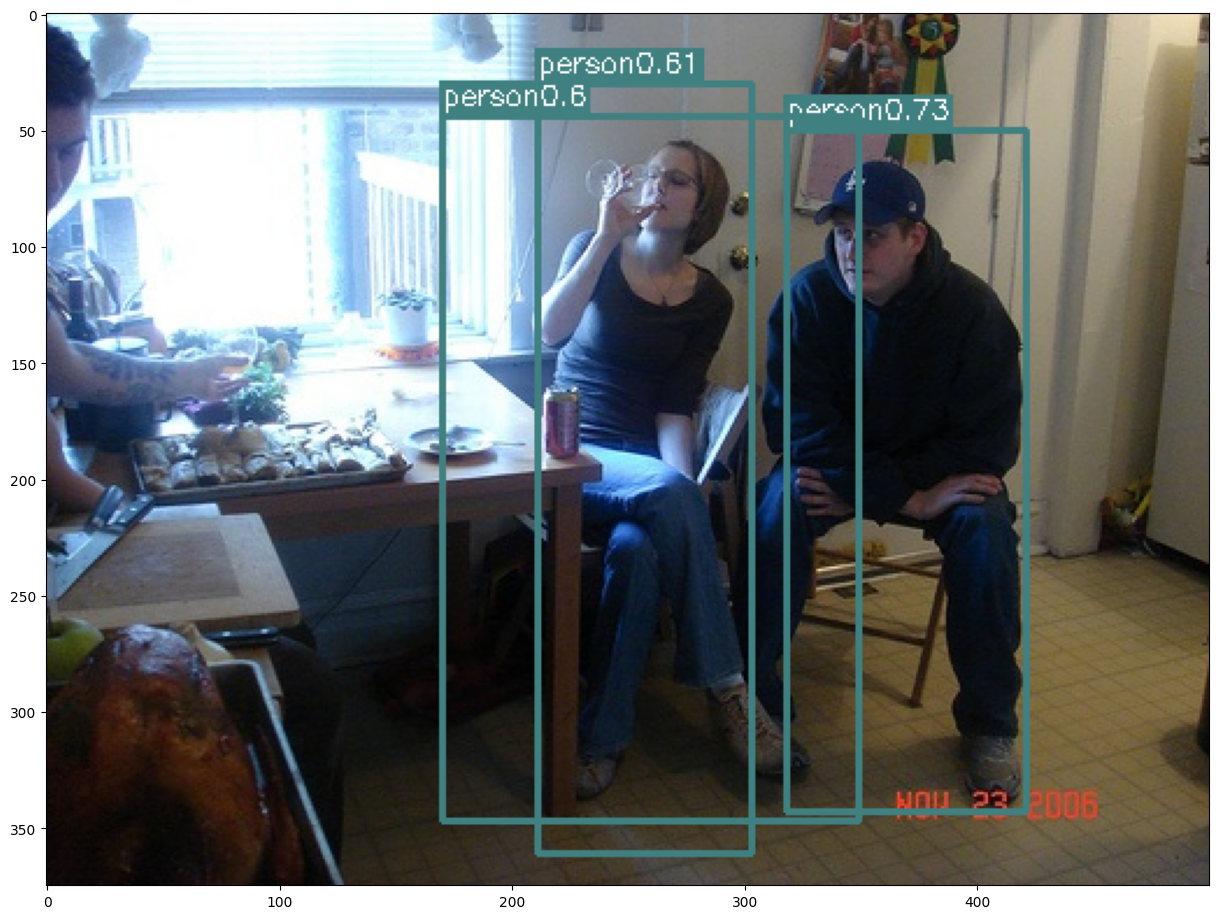

In [44]:
net.eval()

# select random image from test set
image_name = random.choice(test_dataset.fnames)
image = cv2.imread(os.path.join(file_root_test, image_name))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print('predicting...')
result = predict_image(net, image_name, root_img_directory=file_root_test)
for left_up, right_bottom, class_name, _, prob in result:
    color = COLORS[VOC_CLASSES.index(class_name)]
    cv2.rectangle(image, left_up, right_bottom, color, 2)
    label = class_name + str(round(prob, 2))
    text_size, baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)
    p1 = (left_up[0], left_up[1] - text_size[1])
    cv2.rectangle(image, (p1[0] - 2 // 2, p1[1] - 2 - baseline), (p1[0] + text_size[0], p1[1] + text_size[1]),
                  color, -1)
    cv2.putText(image, label, (p1[0], p1[1] + baseline), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, 8)

plt.figure(figsize = (15,15))
plt.imshow(image)


## Evaluate on Test

To evaluate detection results we use mAP (mean of average precision over each class)

In [45]:
test_aps = evaluate(net, test_dataset_file=annotation_file_test, img_root=file_root_test)

---Evaluate model on test samples---


100%|██████████| 4950/4950 [02:52<00:00, 28.75it/s]


---class aeroplane ap 0.4626101043264591---
---class bicycle ap 0.6435716234034479---
---class bird ap 0.5414044770994824---
---class boat ap 0.3594018006152629---
---class bottle ap 0.20502250725743987---
---class bus ap 0.6419972001207144---
---class car ap 0.6816712001831932---
---class cat ap 0.7064055463829715---
---class chair ap 0.2902513872871929---
---class cow ap 0.5146412173213186---
---class diningtable ap 0.3147091290131332---
---class dog ap 0.667325409875408---
---class horse ap 0.7076154916001715---
---class motorbike ap 0.6186272601891523---
---class person ap 0.5303482599729881---
---class pottedplant ap 0.20177836892254739---
---class sheep ap 0.4450926281838938---
---class sofa ap 0.5081544002793246---
---class train ap 0.6794266936576425---
---class tvmonitor ap 0.5304728644295725---
---map 0.5125263785060659---


### Cell added to get intermediate mAP values for students

In [46]:
network_paths = ['./checkpoints/detector_ec2_epoch_%d.pth' % epoch for epoch in [5, 10, 20, 30]]+['./checkpoints/detector_ec2.pth']
for load_network_path in network_paths:
    print('Loading saved network from {}'.format(load_network_path))
    net_loaded = resnet101().to(device)
    net_loaded.load_state_dict(torch.load(load_network_path))
    evaluate(net_loaded, test_dataset_file=annotation_file_test, img_root=file_root_test)


Loading saved network from ./checkpoints/detector_ec2_epoch_5.pth
---Evaluate model on test samples---


100%|██████████| 4950/4950 [02:46<00:00, 29.73it/s]


---class aeroplane ap 0.02056593095642332---
---class bicycle ap 0.05292912549109761---
---class bird ap 0.0--- (no predictions for this class)
---class boat ap 0.0--- (no predictions for this class)
---class bottle ap 0.0--- (no predictions for this class)
---class bus ap 0.0--- (no predictions for this class)
---class car ap 0.1498642979474621---
---class cat ap 0.0--- (no predictions for this class)
---class chair ap 0.0--- (no predictions for this class)
---class cow ap 0.0--- (no predictions for this class)
---class diningtable ap 0.0--- (no predictions for this class)
---class dog ap 0.0--- (no predictions for this class)
---class horse ap 0.0--- (no predictions for this class)
---class motorbike ap 0.0--- (no predictions for this class)
---class person ap 0.1380638966626453---
---class pottedplant ap 0.0--- (no predictions for this class)
---class sheep ap 0.0--- (no predictions for this class)
---class sofa ap 0.0--- (no predictions for this class)
---class train ap 0.0--- (no 

100%|██████████| 4950/4950 [02:49<00:00, 29.21it/s]


---class aeroplane ap 0.29728841333744416---
---class bicycle ap 0.3806792058083751---
---class bird ap 0.2546925591396008---
---class boat ap 0.07408469227191611---
---class bottle ap 0.03479536485372941---
---class bus ap 0.3638522204642268---
---class car ap 0.5243622650465531---
---class cat ap 0.36812847867428855---
---class chair ap 0.1585263802403237---
---class cow ap 0.10690922761420633---
---class diningtable ap 0.09768825756141761---
---class dog ap 0.28509626931167725---
---class horse ap 0.48272480613478025---
---class motorbike ap 0.43592479919403276---
---class person ap 0.261039710413434---
---class pottedplant ap 0.03710702106360895---
---class sheep ap 0.09587175116007338---
---class sofa ap 0.0--- (no predictions for this class)
---class train ap 0.45849376063787195---
---class tvmonitor ap 0.3047526946303688---
---map 0.25110089387789647---
Loading saved network from ./checkpoints/detector_ec2_epoch_20.pth
---Evaluate model on test samples---


...

---class aeroplane ap 0.44808404639176025---
---class bicycle ap 0.6153319005433235---
---class bird ap 0.5095069081086079---
---class boat ap 0.3143415666230119---
---class bottle ap 0.1773492039138843---
---class bus ap 0.5912020678632339---
---class car ap 0.6525868148109255---
---class cat ap 0.7020470543493813---
---class chair ap 0.27040566177359604---
---class cow ap 0.5062968219436773---
---class diningtable ap 0.2714701636587331---
---class dog ap 0.6331678902049823---
---class horse ap 0.6883558530307468---
---class motorbike ap 0.6032414022214264---
---class person ap 0.5179209969729643---
---class pottedplant ap 0.1826935253262143---
---class sheep ap 0.3976407836869199---
---class sofa ap 0.47157646307000245---
---class train ap 0.6778411996648865---
---class tvmonitor ap 0.4966240275556935---
---map 0.4863842175856986---
Loading saved network from ./checkpoints/detector_ec2_epoch_30.pth
---Evaluate model on test samples---


100%|██████████| 4950/4950 [02:51<00:00, 28.78it/s]


---class aeroplane ap 0.4738267833468175---
---class bicycle ap 0.6293618464524028---
---class bird ap 0.5171967555036531---
---class boat ap 0.3600560154474708---
---class bottle ap 0.1953519899555063---
---class bus ap 0.6336162076197556---
---class car ap 0.6689774211789886---
---class cat ap 0.7138107427347258---
---class chair ap 0.29136572575062525---
---class cow ap 0.5184355686815415---
---class diningtable ap 0.29132516057038865---
---class dog ap 0.6676729037171447---
---class horse ap 0.7071089657687222---
---class motorbike ap 0.6370911761239355---
---class person ap 0.5252869380244178---
---class pottedplant ap 0.18835259804882726---
---class sheep ap 0.4525298572856303---
---class sofa ap 0.5212277581950343---
---class train ap 0.6948671049896514---
---class tvmonitor ap 0.5422392776430073---
---map 0.5114850398519123---
Loading saved network from ./checkpoints/detector_ec2.pth
---Evaluate model on test samples---


100%|██████████| 4950/4950 [02:51<00:00, 28.83it/s]


---class aeroplane ap 0.4626101043264591---
---class bicycle ap 0.6435716234034479---
---class bird ap 0.5414044770994824---
---class boat ap 0.3594018006152629---
---class bottle ap 0.20502250725743987---
---class bus ap 0.6419972001207144---
---class car ap 0.6816712001831932---
---class cat ap 0.7064055463829715---
---class chair ap 0.2902513872871929---
---class cow ap 0.5146412173213186---
---class diningtable ap 0.3147091290131332---
---class dog ap 0.667325409875408---
---class horse ap 0.7076154916001715---
---class motorbike ap 0.6186272601891523---
---class person ap 0.5303482599729881---
---class pottedplant ap 0.20177836892254739---
---class sheep ap 0.4450926281838938---
---class sofa ap 0.5081544002793246---
---class train ap 0.6794266936576425---
---class tvmonitor ap 0.5304728644295725---
---map 0.5125263785060659---
